このページではTF-IDFとロジスティック回帰を使って英文フェイクニュースの識別を行う

作成した変数を取り出す

In [1]:
import pickle

with open("../../Data/train_test_split.pkl", "rb") as f:
    x_train, x_test, y_train, y_test = pickle.load(f)

追加の前処理としてNormalizeを行う

In [2]:
import re

def NormalizeText(text):
    text = text.lower() #小文字化
    text = text.replace('\n', ' ') #改行をスペース変換
    text = re.sub(r'[^\w\s]', '', text) #特殊文字を削除
    text = text.strip() #テキストの前後の空白を消去
    return text

x_train_Normalized = x_train.apply(NormalizeText)
x_test_Normalized = x_test.apply(NormalizeText)

TF-IDFを使ってデータを変換する

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

def Tfidf_Limit(limit, x_train, x_test):
    vectorizer = TfidfVectorizer(max_features = limit)
    x_train_tfidf = vectorizer.fit_transform(x_train)
    x_test_tfidf = vectorizer.transform(x_test)
    return x_train_tfidf, x_test_tfidf

x_train_tfidf, x_test_tfidf = Tfidf_Limit(5000, x_train_Normalized, x_test_Normalized)

ロジスティック回帰を使って学習

In [4]:
from sklearn.linear_model import LogisticRegression

def Learning(x_train_tfidf, y_train):
    model = LogisticRegression(max_iter=2000)
    model.fit(x_train_tfidf, y_train)
    return model

model = Learning(x_train_tfidf, y_train)

特徴量5000の時の結果を表示

In [5]:
from sklearn.metrics import classification_report, accuracy_score

def DispResult(model, x_test_tfidf, y_test):
    pred = model.predict(x_test_tfidf)
    print(classification_report(y_test, pred))
    print(accuracy_score(y_test, pred))
    
DispResult(model, x_test_tfidf, y_test)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3472
           1       0.98      0.99      0.99      4258

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730

0.986287192755498


精度と特徴量の関係をグラフにまとめると以下のようになる

[0.5604139715394567, 0.632470892626132, 0.696895213454075, 0.754980595084088, 0.754980595084088, 0.7840879689521345, 0.8714100905562743, 0.9294954721862871, 0.9768434670116429, 0.9840879689521346, 0.9838292367399741, 0.986287192755498]


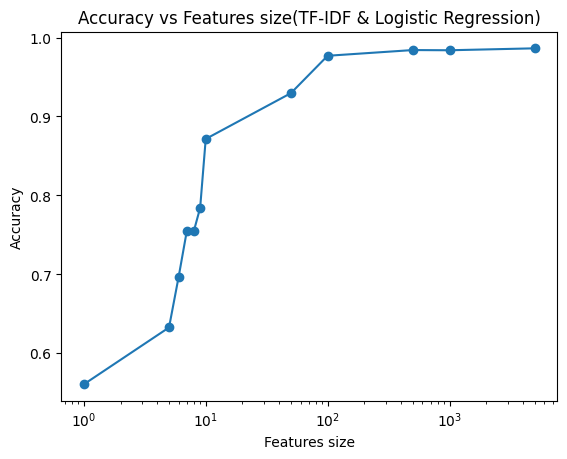

In [9]:
import matplotlib.pyplot as plt

def GetAccuracy(model, x_test_tfidf, y_test):
    y_pred = model.predict(x_test_tfidf)
    return accuracy_score(y_test, y_pred)

features_sizes = [1,5,6,7,8,9,10,50,100,500,1000,5000]
accuracies = [0] *  len(features_sizes)

for i in range(len(features_sizes)):
    x_train_tfidf, x_test_tfidf = Tfidf_Limit(features_sizes[i], x_train_Normalized, x_test_Normalized)
    model = Learning(x_train_tfidf, y_train)
    accuracies[i] = GetAccuracy(model, x_test_tfidf, y_test)

print(accuracies)

plt.plot(features_sizes, accuracies, marker="o")
plt.xlabel("Features size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Features size(TF-IDF & Logistic Regression)")
plt.xscale("log")
plt.show

plt.savefig("../../Figures/TF-IDF&LogisticRegression_accuracy_vs_features_size.png", dpi=300, bbox_inches="tight")